## **Вариант 8** ##

### Рухтина Полина, Маннанова Лилиана, Маликова Камалия 

## Аналитика данных и подготовка ##

## Вступление
В данной работе проводится анализ данных стран мира по индексу искусственного интеллекта (AI Index). Цель исследования — выявить скрытые закономерности в данных и сгруппировать страны на основе их показателей развития ИИ без использования заранее известных меток (обучение без учителя).

После построения моделей кластеризации будет проведён анализ полученных групп, чтобы понять, какие признаки наиболее сильно влияют на распределение стран по кластерам.

## Цели работы:
1. Изучить закономерности в предоставленных данных
2. Применить метод главных компонент (PCA) для снижения размерности
3. Выполнить кластеризацию тремя различными методами
4. Сравнить результаты разных алгоритмов
5. Проанализировать полученные кластеры

### Импорт бибилиотек

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score, calinski_harabasz_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    roc_curve,
    confusion_matrix
)
import joblib
import warnings


In [2]:
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Загрузка данных

In [3]:
df = pd.read_csv('AI_index_db.csv')
display(df.head())
print(f" Датасет загружен: {df.shape[0]} стран, {df.shape[1]} признаков")

,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime
0,United States of America,100.00,94.02,64.56,100.00,100.00,77.39,100.00,100.00,Americas,Power players,High,Liberal democracy
1,China,16.51,100.00,91.57,71.42,79.97,94.87,44.02,62.92,Asia-Pacific,Power players,Upper middle,Closed autocracy
2,United Kingdom,39.65,71.43,74.65,36.50,25.03,82.82,18.91,40.93,Europe,Traditional champions,High,Liberal democracy
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,Traditional champions,High,Liberal democracy
4,Israel,35.76,67.58,82.44,32.63,27.96,43.91,27.33,39.89,Middle East,Rising stars,High,Liberal democracy


 Датасет загружен: 62 стран, 13 признаков


## Описание набора данных
Данные содержат информацию о 62 странах мира, оценивающую их потенциал в сфере искусственного интеллекта. Набор данных состоит из 7 количественных признаков, характеризующих различные аспекты развития ИИ.


## Просмотр набора данных ##

In [4]:
df.sample(10)

,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,Traditional champions,High,Liberal democracy
12,Finland,24.99,71.60,78.76,25.21,18.32,85.99,4.64,31.36,Europe,Rising stars,High,Liberal democracy
52,Indonesia,5.51,47.52,51.18,0.98,3.52,59.99,0.91,11.47,Asia-Pacific,Waking up,Lower middle,Electoral democracy
60,Nigeria,2.74,0.00,50.10,0.45,2.06,7.75,0.33,1.38,Africa,Nascent,Lower middle,Electoral autocracy
19,Hong Kong,17.56,96.11,59.50,31.51,8.63,33.29,5.30,29.11,Asia-Pacific,Waking up,High,Electoral democracy
23,Taiwan,12.34,77.86,56.67,25.71,19.99,55.97,2.53,25.79,Asia-Pacific,Waking up,High,Liberal democracy
8,Germany,27.63,77.22,70.22,35.84,24.79,84.65,8.29,36.04,Europe,Traditional champions,High,Liberal democracy
59,Kenya,0.75,14.11,29.84,0.07,12.15,7.75,0.31,2.30,Africa,Nascent,Lower middle,Electoral autocracy
20,Spain,17.61,73.32,75.36,18.60,10.87,91.28,3.08,26.95,Europe,Rising stars,High,Liberal democracy
14,Luxembourg,21.66,94.88,66.96,19.39,19.95,66.69,4.68,30.73,Europe,Waking up,High,Liberal democracy


Просмотрели 10 случайных запиисей для проверки данных на аномалия.

In [5]:
display(df[['Total score', 'Talent', 'Infrastructure', 'Research', 'Development']].describe().round(2))

,Total score,Talent,Infrastructure,Research,Development
count,62.00,62.00,62.00,62.00,62.00
mean,23.91,16.80,63.50,16.61,14.82
std,15.12,15.21,20.22,17.41,19.42
min,0.00,0.00,0.00,0.00,0.00
25%,14.80,7.36,55.86,3.03,1.20
50%,23.22,13.44,65.23,12.93,9.00
75%,30.49,24.57,75.95,25.41,19.98
max,100.00,100.00,100.00,100.00,100.00


### ОПИСАНИЕ ПРИЗНАКОВ ###

Country - Название страны

Talent - Уровень талантов и кадров в сфере ИИ 

Infrastructure - Технологическая инфраструктура 

Operating Environment - Условия для ведения бизнеса

Research - Научные исследования в области ИИ 

Development - Практическая разработка ИИ-решений 

Government Strategy - Государственная стратегия по ИИ 

Commercial - Коммерциализация ИИ-технологий 

Total score - Итоговый рейтинг страны 

Region - Географический регион

Cluster - Группа развития ИИ (Power players, Traditional champions, и т.д.)

Income group - Уровень дохода страны

Political regime - Политический режим

 62 стран, 13 признаков

# Проверка на пропущенные данные


In [6]:
df.isnull().sum()

Country                  0
Talent                   0
Infrastructure           0
Operating Environment    0
Research                 0
Development              0
Government Strategy      0
Commercial               0
Total score              0
Region                   0
Cluster                  0
Income group             0
Political regime         0
dtype: int64

 убедились, что в нашем датасете нет пропущенных значений, 
 все 62 страны имеют полные данные по всем признакам

# Проверка дублирования, вывод статистики


In [7]:
df.duplicated().value_counts()

False    62
Name: count, dtype: int64

In [8]:
df.shape

(62, 13)

 видим, что у нас нет дубликатов, все 62 страны уникальны, 
   значит можем не беспокоиться о повторяющихся значениях

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                62 non-null     object 
 1   Talent                 62 non-null     float64
 2   Infrastructure         62 non-null     float64
 3   Operating Environment  62 non-null     float64
 4   Research               62 non-null     float64
 5   Development            62 non-null     float64
 6   Government Strategy    62 non-null     float64
 7   Commercial             62 non-null     float64
 8   Total score            62 non-null     float64
 9   Region                 62 non-null     object 
 10  Cluster                62 non-null     object 
 11  Income group           62 non-null     object 
 12  Political regime       62 non-null     object 
dtypes: float64(8), object(5)
memory usage: 6.4+ KB


Вывели информацию по нашему датасету, видим, что все значения на месте, 

нет пропущенных значений. 8 признаков представляют собой числовой тип                
данных (float64), также видим, что есть 5 признаков с типом данных object                       
(Country, Region, Cluster, Income group, Political regime).

In [10]:
df.describe()

,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,16.803065,63.503710,66.925484,16.610000,14.824677,57.865645,6.171935,23.914677
std,15.214963,20.217525,20.000424,17.413996,19.419279,26.252448,14.029632,15.123586
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.365000,55.857500,58.107500,3.032500,1.202500,41.030000,0.697500,14.805000
50%,13.445000,65.230000,69.505000,12.930000,9.005000,63.930000,2.585000,23.220000
75%,24.567500,75.947500,80.500000,25.412500,19.980000,77.952500,5.307500,30.487500
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


По данной статистике видим некоторые значения:

Развитие ИИ: В среднем страны имеют низкие показатели по Research (16.61) 
и Development (14.82), что говорит нам о том, что большинство стран только 
начинают развивать эти направления.

Инфраструктура: Средний показатель Infrastructure - 63.5, что является 
наиболее развитым аспектом. Это значит, что техническая база развита лучше 
других сфер.

Общий рейтинг: Средний Total score составляет 23.91 балла из 100, что 
подтверждает сильное неравенство - большинство стран отстают от лидеров.

Коммерциализация: Самый низкий средний показатель - Commercial (6.2), 
что говорит о слабом внедрении ИИ-технологий в бизнес.

## КОРРЕЛЯЦИИ МЕЖДУ ПРИЗНАКАМИ" ##

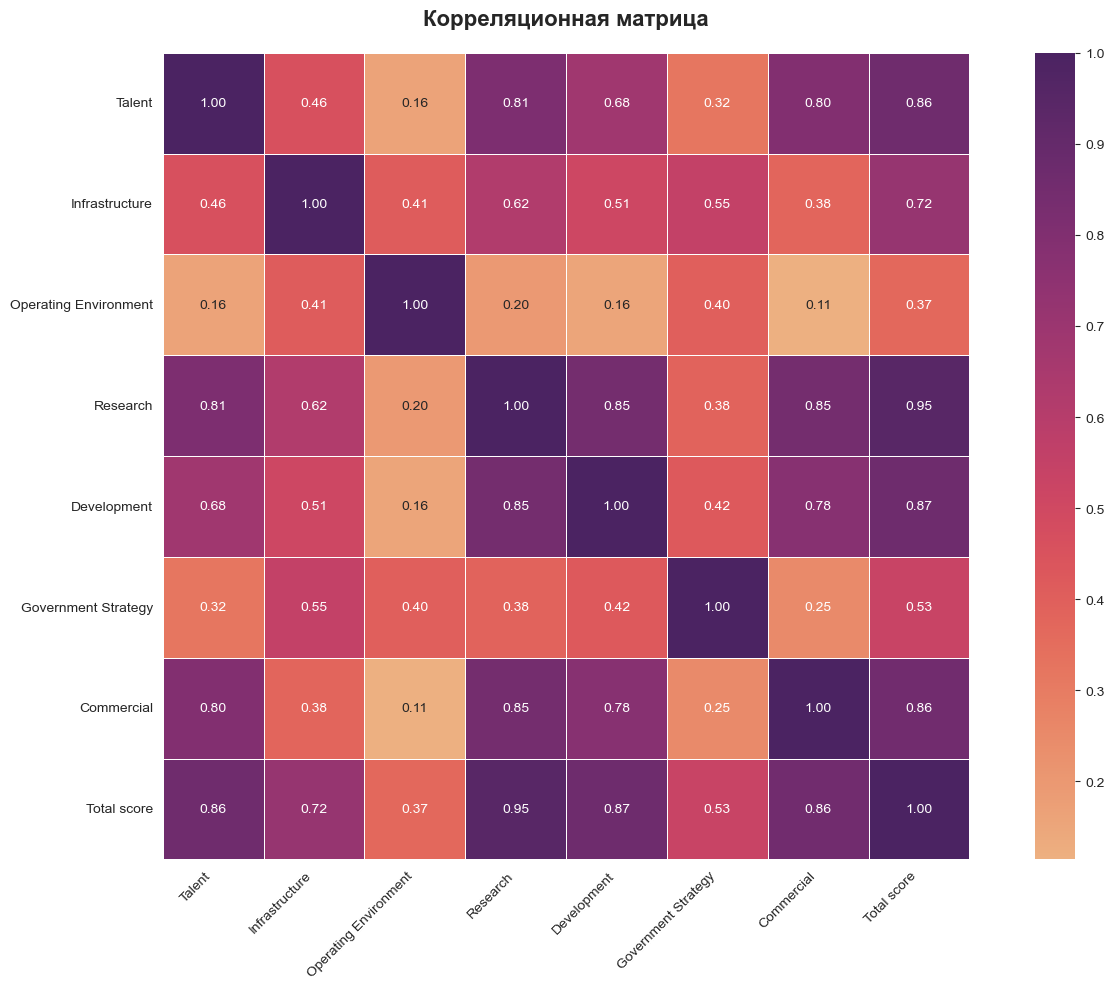

In [11]:
num_cols = ['Talent', 'Infrastructure', 'Operating Environment', 'Research', 
            'Development', 'Government Strategy', 'Commercial', 'Total score']

plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols].corr(), 
            cmap=sns.color_palette("flare", as_cmap=True), 
            annot=True, 
            fmt='.2f',
            vmax=1.0,
            square=True,
            linewidths=0.5)
plt.title('Корреляционная матрица', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [12]:
corr_with_total = df[num_cols].corr()['Total score'].sort_values(ascending=False)
display(corr_with_total[1:].round(3))

Research                 0.946
Development              0.866
Talent                   0.862
Commercial               0.858
Infrastructure           0.716
Government Strategy      0.532
Operating Environment    0.369
Name: Total score, dtype: float64


- **Сильные положительные корреляции** (0.7-1.0): некоторые признаки сильно связаны между собой
- **Слабые корреляции** (0.0-0.3): некоторые признаки независимы друг от друга
- **Наиболее коррелирующие с Total score:** признаки Research, Development, Talent

### Вывод:
- Высокие корреляции между признаками могут указывать на избыточность информации
- PCA поможет снизить размерность и убрать коррелированные признаки
- Все признаки важны для итогового scores, но в разной степени

## РАСПРЕДЕЛЕНИЕ ДАННЫХ ##

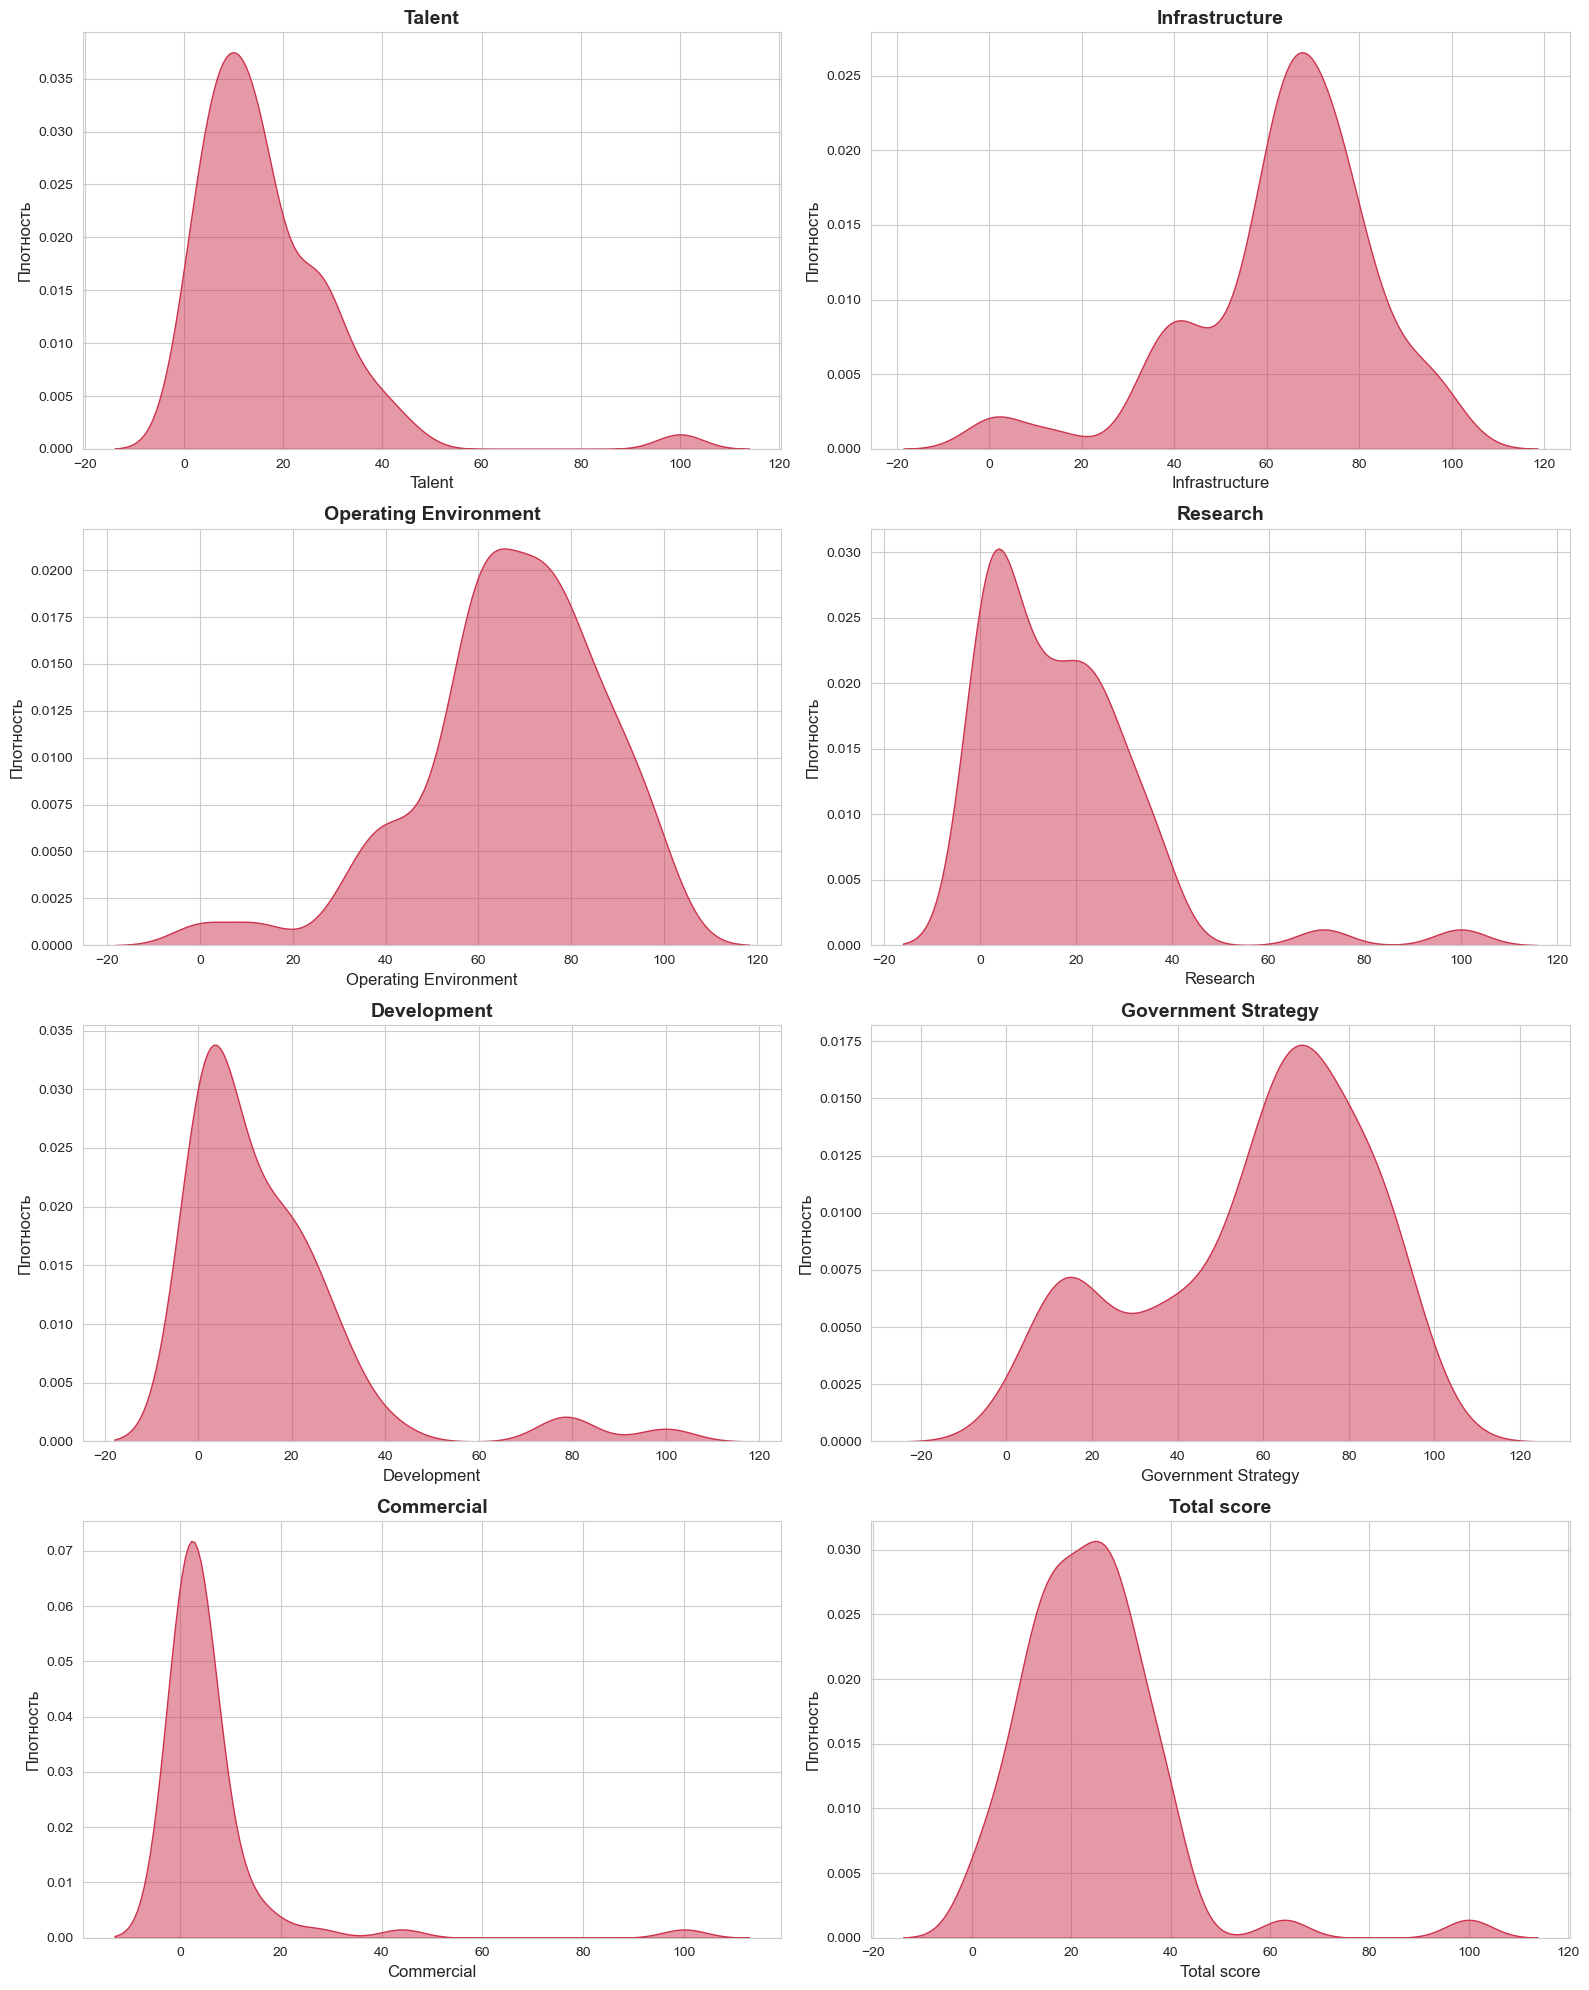


 Выводы:
   • Некоторые признаки близки к нормальному распределению
   • Остальные имеют скос или несколько мод
   • Признаки имеют разные масштабы измерений → нужна нормализация



In [13]:

features = ['Talent', 'Infrastructure', 'Operating Environment', 'Research', 
            'Development', 'Government Strategy', 'Commercial']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
plt.subplots_adjust(hspace=0.5)

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, fill=True, alpha=0.5, bw_adjust=0.7, 
                color=[0.8, 0.2, 0.3], ax=axes[i])
    axes[i].set_title(col, fontweight='bold', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Плотность', fontsize=12)

sns.kdeplot(data=df, x='Total score', fill=True, alpha=0.5, bw_adjust=0.7, 
            color=[0.8, 0.2, 0.3], ax=axes[7])
axes[7].set_title('Total score', fontweight='bold', fontsize=14)
axes[7].set_xlabel('Total score', fontsize=12)
axes[7].set_ylabel('Плотность', fontsize=12)

plt.tight_layout()
plt.show()

print("""
 Выводы:
   • Некоторые признаки близки к нормальному распределению
   • Остальные имеют скос или несколько мод
   • Признаки имеют разные масштабы измерений → нужна нормализация
""")

## Выбросы данных

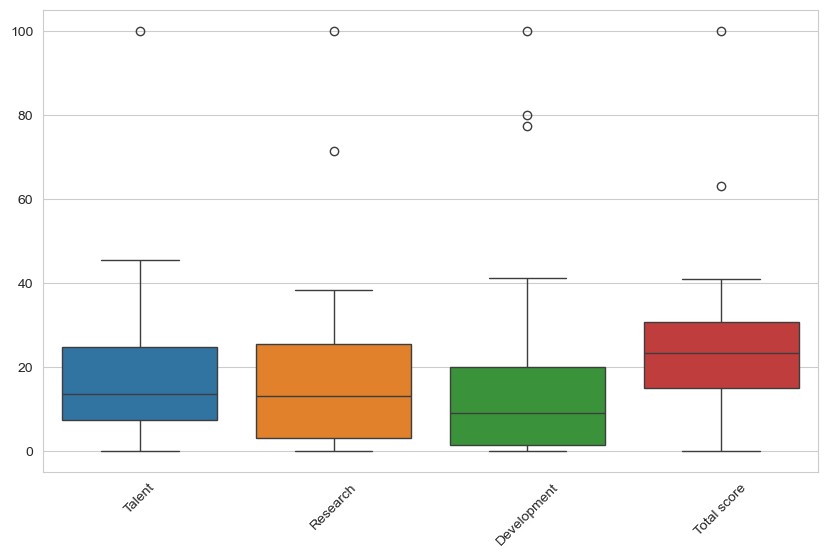

In [14]:
cols = ['Talent', 'Research', 'Development', 'Total score']
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[cols])
plt.xticks(rotation=45)
plt.show()

In [15]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"\n{col}:")
    print(f"  Границы: от {lower:.1f} до {upper:.1f}")
    print(f"  Найдено выбросов: {len(outliers)}")
    
    if len(outliers) > 0:
        print(f"  Страны: {', '.join(outliers['Country'].tolist())}")


Talent:
  Границы: от -18.4 до 50.4
  Найдено выбросов: 1
  Страны: United States of America

Research:
  Границы: от -30.5 до 59.0
  Найдено выбросов: 2
  Страны: United States of America, China

Development:
  Границы: от -27.0 до 48.1
  Найдено выбросов: 3
  Страны: United States of America, China, South Korea

Total score:
  Границы: от -8.7 до 54.0
  Найдено выбросов: 2
  Страны: United States of America, China


Размер: (62, 9)
Всего найдено выбросов: 20


,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Total outliers
Country,,,,,,,,,
United States of America,1,0,0,1,1,0,1,1,5
China,0,0,0,1,1,0,1,1,4
United Kingdom,0,0,0,0,0,0,1,0,1
Canada,0,0,0,0,0,0,1,0,1
Israel,0,0,0,0,0,0,1,0,1
Singapore,0,0,0,0,0,0,1,0,1
South Korea,0,0,0,0,1,0,0,0,1
Estonia,0,0,0,0,0,0,1,0,1
Egypt,0,0,1,0,0,0,0,0,1


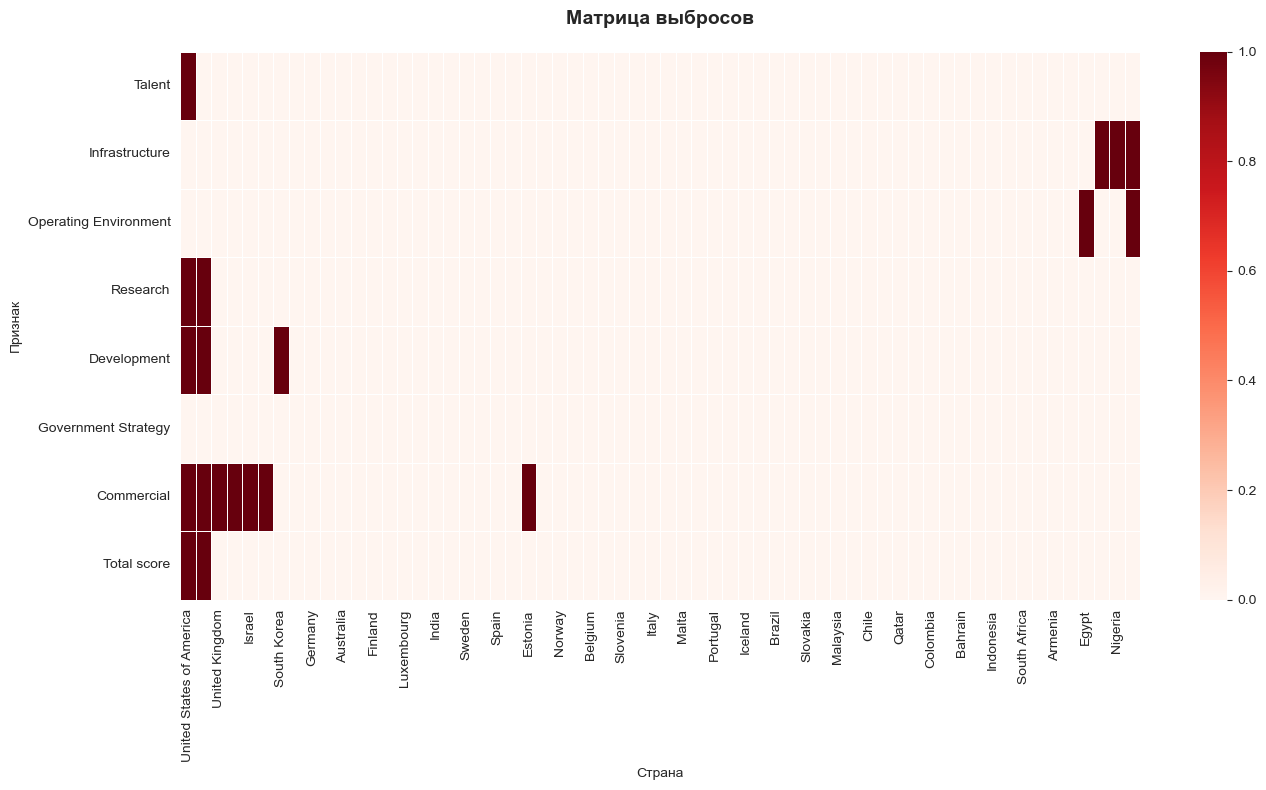

In [16]:
numeric_cols = ['Talent', 'Infrastructure', 'Operating Environment', 
                'Research', 'Development', 'Government Strategy', 
                'Commercial', 'Total score']

# Создаем DataFrame
outlier_summary = pd.DataFrame(index=df.index)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outlier_mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    outlier_summary[col] = outlier_mask.astype(int)

# Добавляем названия стран и устанавливаем как индекс
outlier_summary['Country'] = df['Country'].values
outlier_summary = outlier_summary.set_index('Country') 
outlier_summary['Total outliers'] = outlier_summary[numeric_cols].sum(axis=1)

# Проверяем
print(f"Размер: {outlier_summary.shape}")
print(f"Всего найдено выбросов: {outlier_summary['Total outliers'].sum()}")
display(outlier_summary[outlier_summary['Total outliers'] > 0].head(10))

# Рисуем heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(outlier_summary[numeric_cols].T, 
            cmap='Reds', 
            linewidths=0.5)
plt.title('Матрица выбросов', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Страна')
plt.ylabel('Признак')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## НОРМАЛИЗАЦИЯ ##

In [17]:
scaler = MinMaxScaler()
X = df[features].copy()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)
display(X_scaled.describe().round(3))
print(" MinMaxScaler применён (диапазон [0, 1])")

,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial
count,62.000,62.000,62.000,62.000,62.000,62.000,62.000
mean,0.168,0.635,0.669,0.166,0.148,0.579,0.062
std,0.152,0.202,0.200,0.174,0.194,0.263,0.140
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.074,0.559,0.581,0.030,0.012,0.410,0.007
50%,0.134,0.652,0.695,0.129,0.090,0.639,0.026
75%,0.246,0.759,0.805,0.254,0.200,0.780,0.053
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


 MinMaxScaler применён (диапазон [0, 1])



- Все 7 признаков приведены к диапазону [0, 1]
- Минимальное значение каждого признака стало 0.000
- Максимальное значение каждого признака стало 1.000

- **mean ≈ 0.3-0.5:** средние значения распределились по диапазону
- **std ≈ 0.2-0.3:** стандартное отклонение уменьшилось и выровнялось
- **min = 0.000, max = 1.000:** все признаки теперь в одном масштабе

# Кластеризация (3 метода), метрики, визуализация.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [19]:
features_for_clustering = ['Talent', 'Infrastructure', 'Operating Environment', 
                          'Research', 'Development', 'Government Strategy', 'Commercial']

X = df[features_for_clustering].copy()
print("\nРазмер матрицы признаков:", X.shape)
X.head()


Размер матрицы признаков: (62, 7)


,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial
0,100.00,94.02,64.56,100.00,100.00,77.39,100.00
1,16.51,100.00,91.57,71.42,79.97,94.87,44.02
2,39.65,71.43,74.65,36.50,25.03,82.82,18.91
3,31.28,77.05,93.94,30.67,25.78,100.00,14.88
4,35.76,67.58,82.44,32.63,27.96,43.91,27.33


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)

print("Данные после масштабирования:")
X_scaled_df.head()

Данные после масштабирования:


,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial
0,5.512738,1.521720,-0.119237,4.827769,4.421927,0.749787,6.742445
1,-0.019419,1.819917,1.242259,3.173162,3.382058,1.421065,2.719746
2,1.513868,0.395251,0.389370,1.151509,0.529815,0.958313,0.915352
3,0.959261,0.675497,1.361723,0.813988,0.568752,1.618071,0.625758
4,1.256111,0.203268,0.782042,0.927460,0.681928,-0.535934,1.520410


Подключили библиотеки.
Взяли 7 признаков, по которымм будем делать кластеризацию.
Просмотрели данные (у нас есть 62 страны и 7 признаков для каждого обьекта).
Провели масштабирование данных.

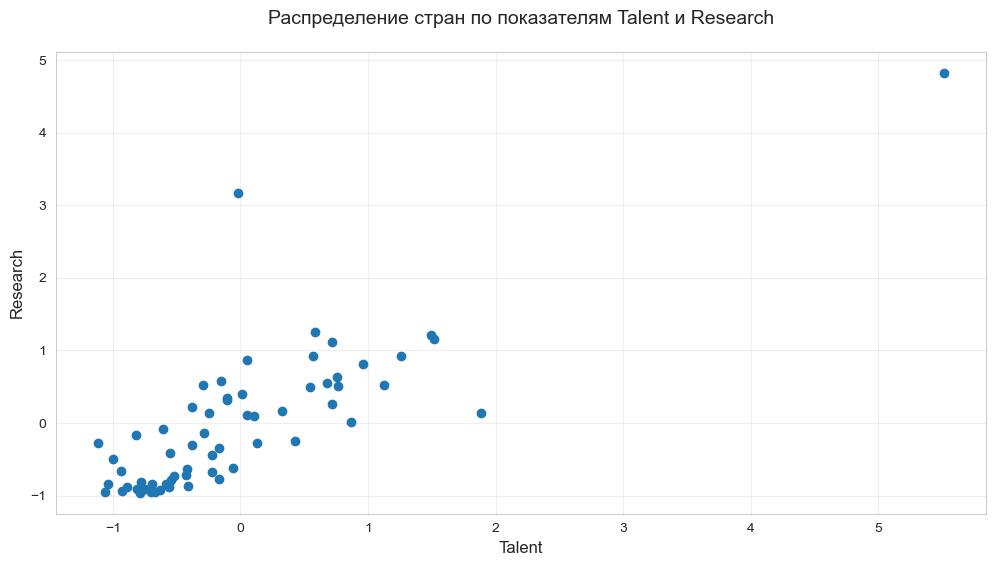

In [21]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 3])
plt.xlabel('Talent', fontsize=12)
plt.ylabel('Research', fontsize=12)
plt.title('Распределение стран по показателям Talent и Research', fontsize=14, pad=20)
plt.grid(True, alpha=0.3)
plt.show()

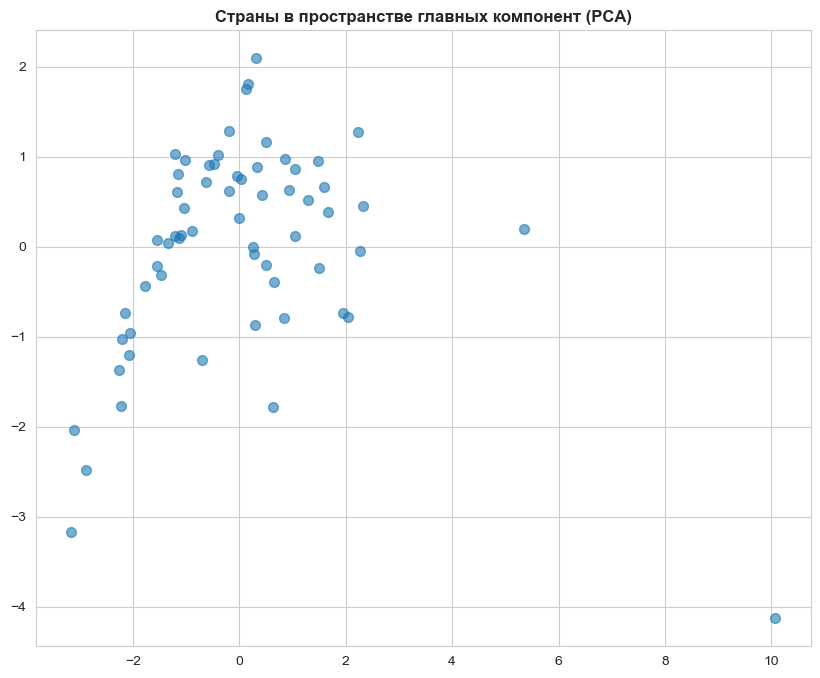

In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=50)
plt.title('Страны в пространстве главных компонент (PCA)', fontsize=12, fontweight='bold')

plt.show()

## МЕТОД ЛОКТЯ (Elbow Method)

In [23]:
inertia = [] 
K_range = range(2, 11) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_) 

## МЕТОД СИЛУЭТА (Silhouette Method)

In [24]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

### Визуализируем оба метода

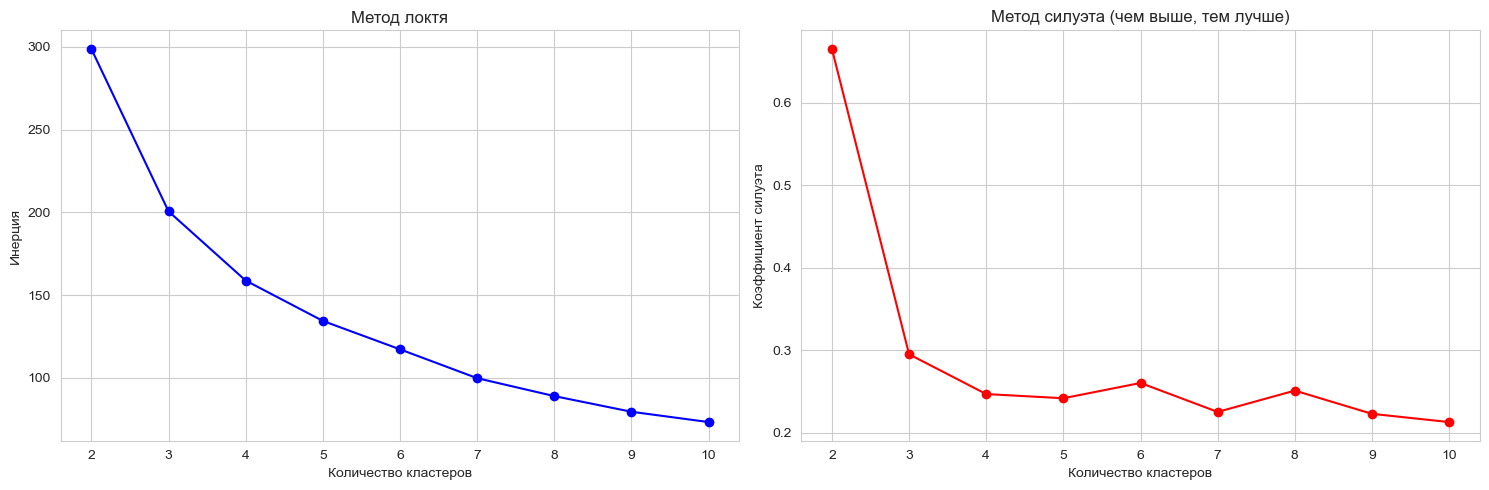

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График локтя
ax1.plot(K_range, inertia, 'bo-')
ax1.set_xlabel('Количество кластеров')
ax1.set_ylabel('Инерция')
ax1.set_title('Метод локтя')
ax1.grid(True)


# График силуэта
ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Количество кластеров')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Метод силуэта (чем выше, тем лучше)')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [26]:
best_k = K_range[np.argmax(silhouette_scores)]
print(f"Оптимальное количество кластеров: {best_k}")
print(f"Коэффициент силуэта: {max(silhouette_scores):.3f}")

Оптимальное количество кластеров: 2
Коэффициент силуэта: 0.665


Мы провели анализ для определения оптимального количества кластеров в данных, используя два метода. Протестировали с количеством кластеров от 2 до 10. Построили графики.
Метод локтя показывает инерцию для кваждого k, нам необходимо найти точку, где уменьшение инерции замедляется.
Мктод силуэта оценивает качество кластеризаци.

Нашли что оптимальное количество кластеров - 2. Значит наши данные лучше всего разделяются на 2 кластера с достаточно высоким качеством разделения.

### Метод - K-MEANS

In [27]:
n_cl = 3
kmeans = KMeans(n_clusters=n_cl, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

silhouette = silhouette_score(X_scaled, df['cluster_kmeans'])
print(f"Коэффициент силуэта: {silhouette:.3f}")

df.head()

Коэффициент силуэта: 0.295


,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime,cluster_kmeans
0,United States of America,100.00,94.02,64.56,100.00,100.00,77.39,100.00,100.00,Americas,Power players,High,Liberal democracy,2
1,China,16.51,100.00,91.57,71.42,79.97,94.87,44.02,62.92,Asia-Pacific,Power players,Upper middle,Closed autocracy,2
2,United Kingdom,39.65,71.43,74.65,36.50,25.03,82.82,18.91,40.93,Europe,Traditional champions,High,Liberal democracy,0
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,Traditional champions,High,Liberal democracy,0
4,Israel,35.76,67.58,82.44,32.63,27.96,43.91,27.33,39.89,Middle East,Rising stars,High,Liberal democracy,0


Выполнили кластеризацию стран с помощью метода K-means. Количество кластеров взяли как k = 3.
Применили алгоритм к масштабированным данным. 
Коэффициент силуэта: 0.295 (довольно низкий, он говорит о нечётком разделении).

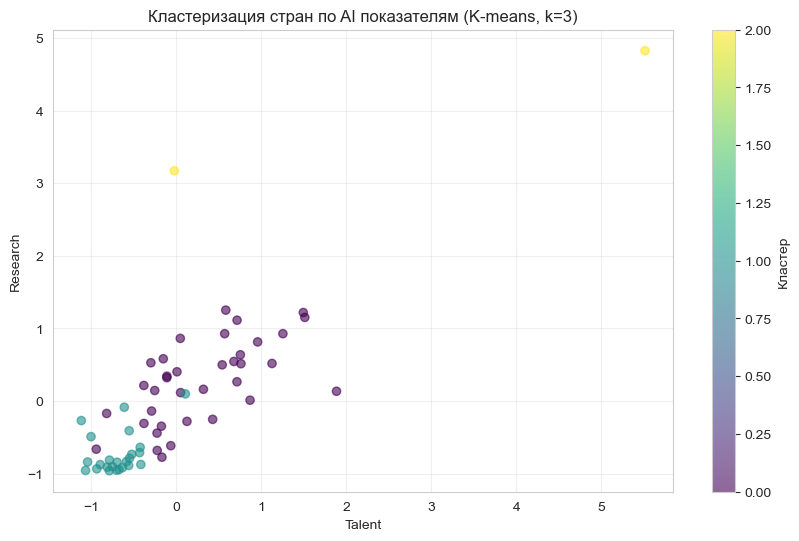

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 3], c=df['cluster_kmeans'], cmap='viridis', alpha=0.6)
plt.xlabel('Talent')
plt.ylabel('Research')
plt.title('Кластеризация стран по AI показателям (K-means, k=3)')
plt.colorbar(label='Кластер')
plt.grid(True, alpha=0.3)
plt.show()


Сделали визуализацию. Построили scatter plot по осям Talent vs Research.
Кластер 0 (фиолетовый, содержит 36 стран) — основная масса стран с низкими/средними показателями.
Кластер 1 (бирюзовый, содержит 24 страны) — промежуточная группа.
Кластер 2 (жёлтый, содержит 2 страны) — лидеры (США и Китай).

In [29]:
df.groupby('cluster_kmeans')[features_for_clustering].mean()
df['cluster_kmeans'].value_counts().sort_index()


cluster_kmeans
0    36
1    24
2     2
Name: count, dtype: int64

In [30]:
for cluster in range(3):
    countries = df[df['cluster_kmeans'] == cluster]['Country'].head(4).tolist()
    print(f"Кластер {cluster}: {', '.join(countries)}")

Кластер 0: United Kingdom, Canada, Israel, Singapore
Кластер 1: Iceland, Greece, Slovakia, Hungary
Кластер 2: United States of America, China


Посмотрели распределение по кластерам с примерами стран.

Вывод: данные имеют явную иерархическую структуру с двумя доминирующими странами и остальными, сгруппированными по уровню развития AI.

### Метод - Agglomerative (Иерархическая)

In [31]:
n_cl = 3  

agglo = AgglomerativeClustering(n_clusters=n_cl)
df['cluster_agglo'] = agglo.fit_predict(X_scaled)
print(f"Agglomerative Clustering: {silhouette_score(X_scaled, df['cluster_agglo']):.3f}")

df.head()

Agglomerative Clustering: 0.277


,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime,cluster_kmeans,cluster_agglo
0,United States of America,100.00,94.02,64.56,100.00,100.00,77.39,100.00,100.00,Americas,Power players,High,Liberal democracy,2,1
1,China,16.51,100.00,91.57,71.42,79.97,94.87,44.02,62.92,Asia-Pacific,Power players,Upper middle,Closed autocracy,2,0
2,United Kingdom,39.65,71.43,74.65,36.50,25.03,82.82,18.91,40.93,Europe,Traditional champions,High,Liberal democracy,0,0
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,Traditional champions,High,Liberal democracy,0,0
4,Israel,35.76,67.58,82.44,32.63,27.96,43.91,27.33,39.89,Middle East,Rising stars,High,Liberal democracy,0,0


Выполнили иерархическую кластеризацию с 3 кластерами.
Коэффициент силуэта: 0.277 (низкий, указывает на нечеткое разделение)

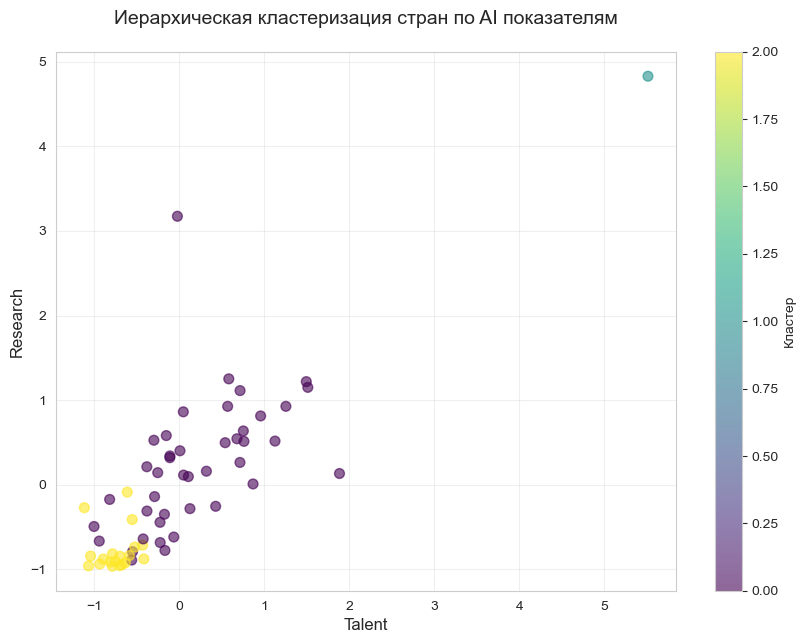

In [32]:
plt.figure(figsize=(10, 7))
plt.scatter(X_scaled[:, 0], X_scaled[:, 3], c=df['cluster_agglo'], cmap='viridis', alpha=0.6, s=50)
plt.xlabel('Talent', fontsize=12)
plt.ylabel('Research', fontsize=12)
plt.title('Иерархическая кластеризация стран по AI показателям', fontsize=14, pad=20)
plt.colorbar(label='Кластер')
plt.grid(True, alpha=0.3)
plt.show()


Сделали визуализацию. Построили scatter plot по осям Talent vs Research. Данный кластер схож с методом K-means.

In [33]:
print(df['cluster_agglo'].value_counts().sort_index())

print("\nПримеры стран в каждом кластере:")
for cluster in range(n_cl):
    countries = df[df['cluster_agglo'] == cluster]['Country'].head(3).tolist()
    print(f"Кластер {cluster}: {', '.join(countries)}")

cluster_agglo
0    42
1     1
2    19
Name: count, dtype: int64

Примеры стран в каждом кластере:
Кластер 0: China, United Kingdom, Canada
Кластер 1: United States of America
Кластер 2: Greece, Hungary, Chile


Посмотрели распределение по кластерам с примерами стран.

### Gaussian Mixture Model (Модель смеси Гаусса)

In [34]:
gmm = GaussianMixture(n_components=3, random_state=42, n_init=10)
df['cluster_gmm'] = gmm.fit_predict(X_scaled)

silhouette = silhouette_score(X_scaled, df['cluster_gmm'])
print(f"Коэффициент силуэта: {silhouette:.3f}")

df.head()

Коэффициент силуэта: 0.197


,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime,cluster_kmeans,cluster_agglo,cluster_gmm
0,United States of America,100.00,94.02,64.56,100.00,100.00,77.39,100.00,100.00,Americas,Power players,High,Liberal democracy,2,1,0
1,China,16.51,100.00,91.57,71.42,79.97,94.87,44.02,62.92,Asia-Pacific,Power players,Upper middle,Closed autocracy,2,0,0
2,United Kingdom,39.65,71.43,74.65,36.50,25.03,82.82,18.91,40.93,Europe,Traditional champions,High,Liberal democracy,0,0,0
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,Traditional champions,High,Liberal democracy,0,0,2
4,Israel,35.76,67.58,82.44,32.63,27.96,43.91,27.33,39.89,Middle East,Rising stars,High,Liberal democracy,0,0,0


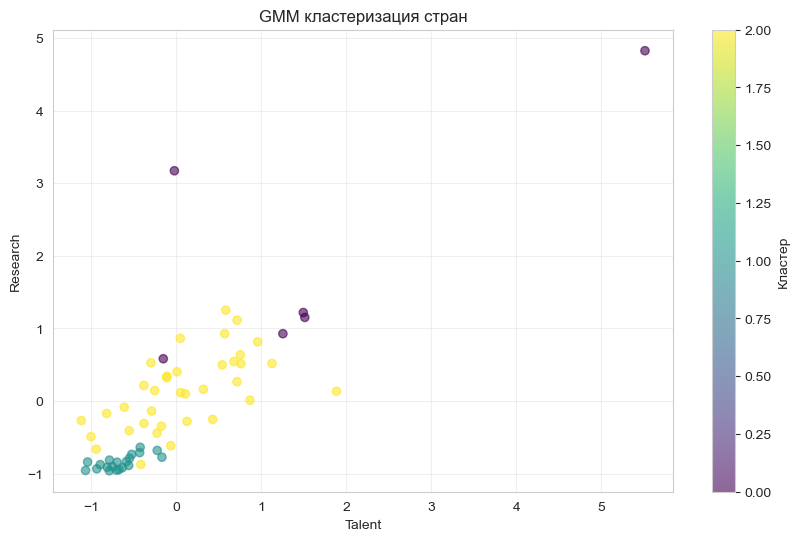

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 3], c=df['cluster_gmm'], cmap='viridis', alpha=0.6)
plt.xlabel('Talent')
plt.ylabel('Research')
plt.title('GMM кластеризация стран')
plt.colorbar(label='Кластер')
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
print(df['cluster_gmm'].value_counts().sort_index())

print("\nПримеры стран в каждом кластере:")
for cluster in range(3):
    countries = df[df['cluster_gmm'] == cluster]['Country'].head(3).tolist()
    print(f"Кластер {cluster}: {', '.join(countries)}")

cluster_gmm
0     6
1    20
2    36
Name: count, dtype: int64

Примеры стран в каждом кластере:
Кластер 0: United States of America, China, United Kingdom
Кластер 1: Lithuania, Brazil, Slovakia
Кластер 2: Canada, The Netherlands, Germany


Выполнили кластеризацию стран с помощью метода Gaussian Mixture Model (GMM).
Количество кластеров взяли как k = 3.
Применили алгоритм к масштабированным данным.
Коэффициент силуэта - 0.197

### Сравнение методов кластеризации

In [37]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=3, random_state=42, n_init=10)
gmm_labels = gmm.fit_predict(X_scaled)

comparison = pd.DataFrame({
    'Метод': ['K-Means', 'Agglomerative', 'GMM'],
    'Силуэт': [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, agglo_labels),
        silhouette_score(X_scaled, gmm_labels)
    ],
    'Кластеров': [
        len(set(kmeans_labels)),
        len(set(agglo_labels)),
        len(set(gmm_labels))
    ]
})
print(comparison.round(3))

           Метод  Силуэт  Кластеров
0        K-Means   0.295          3
1  Agglomerative   0.277          3
2            GMM   0.197          3


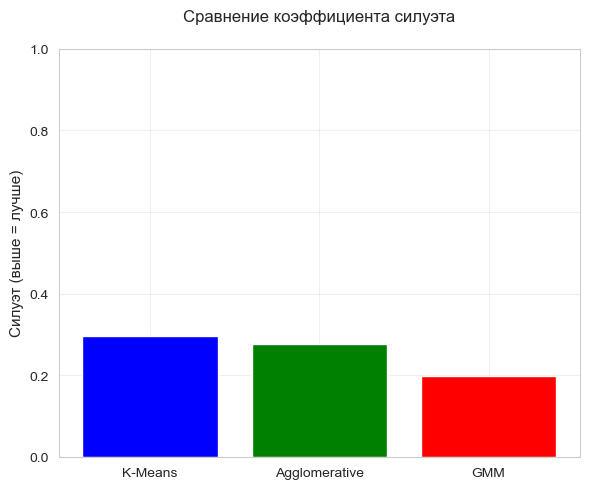


Лучший метод: K-Means
Коэффициент силуэта: 0.295


In [38]:
fig, ax = plt.subplots(figsize=(6, 5))  # или (1, 1)

ax.bar(comparison['Метод'], comparison['Силуэт'], color=['blue', 'green', 'red'])
ax.set_title('Сравнение коэффициента силуэта', fontsize=12, pad=20)
ax.set_ylabel('Силуэт (выше = лучше)', fontsize=11)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_method = comparison.loc[comparison['Силуэт'].idxmax()]
print(f"\nЛучший метод: {best_method['Метод']}")
print(f"Коэффициент силуэта: {best_method['Силуэт']:.3f}")

In [39]:
comparison_df = df[['Country']].copy()
comparison_df['K-Means'] = kmeans_labels
comparison_df['Agglomerative'] = agglo_labels
comparison_df['GMM'] = gmm_labels

comparison_df['Region'] = df['Region']

comparison_df.head(15)

,Country,K-Means,Agglomerative,GMM,Region
0,United States of America,2,1,0,Americas
1,China,2,0,0,Asia-Pacific
2,United Kingdom,0,0,0,Europe
3,Canada,0,0,2,Americas
4,Israel,0,0,0,Middle East
5,Singapore,0,0,0,Asia-Pacific
6,South Korea,0,0,0,Asia-Pacific
7,The Netherlands,0,0,2,Europe
8,Germany,0,0,2,Europe
9,France,0,0,2,Europe


Выводим первые 15 стран для сравнение кластеризации 

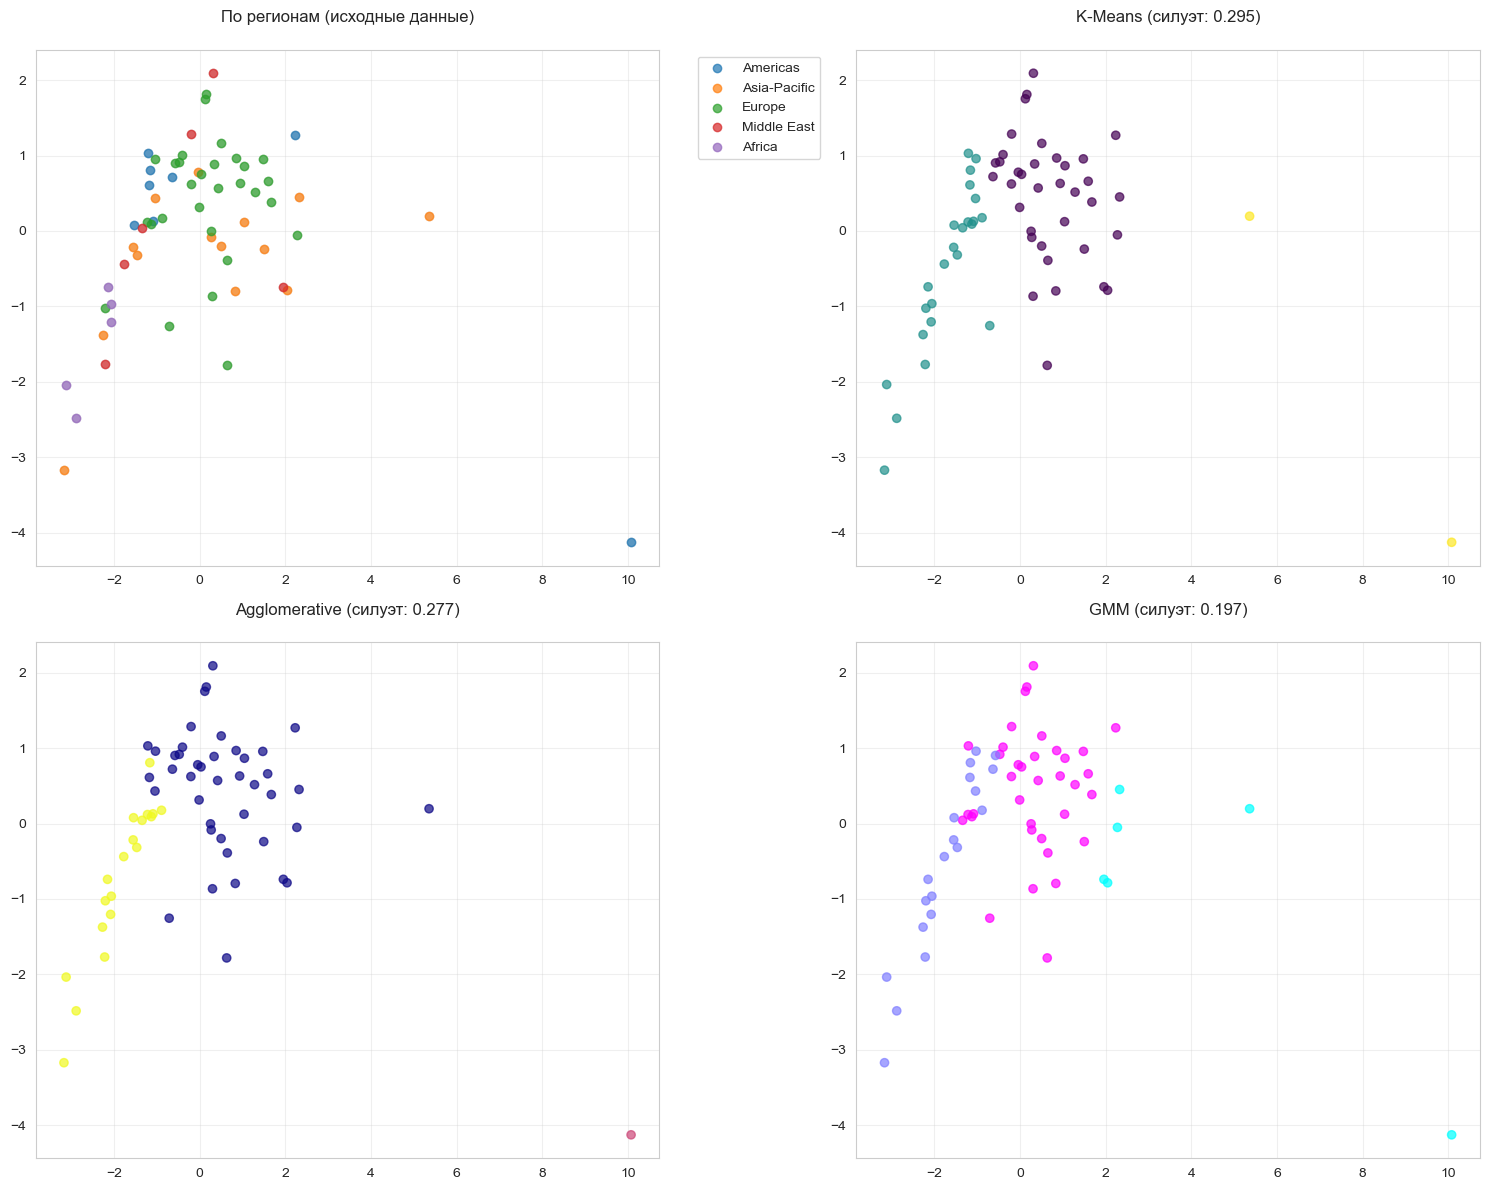

PC1 объясняет: 58.1% дисперсии
PC2 объясняет: 19.1% дисперсии
Всего: 77.3% общей дисперсии


In [40]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

viz_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Country': df['Country'],
    'Region': df['Region'],
    'KMeans': kmeans_labels,
    'Agglomerative': agglo_labels,
    'GMM': gmm_labels
})

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# по регионам (исходные данные)
axes[0, 0].scatter(viz_df['PC1'], viz_df['PC2'], c='lightgray', alpha=0.6)
for region in viz_df['Region'].unique():
    mask = viz_df['Region'] == region
    axes[0, 0].scatter(viz_df.loc[mask, 'PC1'], viz_df.loc[mask, 'PC2'], 
                       label=region, alpha=0.7)
axes[0, 0].set_title('По регионам (исходные данные)', fontsize=12, pad=20)
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].grid(True, alpha=0.3)

# K-Means
scatter = axes[0, 1].scatter(viz_df['PC1'], viz_df['PC2'], 
                              c=viz_df['KMeans'], cmap='viridis', alpha=0.7)
axes[0, 1].set_title(f'K-Means (силуэт: {silhouette_score(X_scaled, kmeans_labels):.3f})', 
                     fontsize=12, pad=20)
axes[0, 1].grid(True, alpha=0.3)

# Agglomerative
scatter = axes[1, 0].scatter(viz_df['PC1'], viz_df['PC2'], 
                              c=viz_df['Agglomerative'], cmap='plasma', alpha=0.7)
axes[1, 0].set_title(f'Agglomerative (силуэт: {silhouette_score(X_scaled, agglo_labels):.3f})', 
                     fontsize=12, pad=20)
axes[1, 0].grid(True, alpha=0.3)

# GMM
scatter = axes[1, 1].scatter(viz_df['PC1'], viz_df['PC2'], 
                              c=viz_df['GMM'], cmap='cool', alpha=0.7)
axes[1, 1].set_title(f'GMM (силуэт: {silhouette_score(X_scaled, gmm_labels):.3f})', 
                     fontsize=12, pad=20)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PC1 объясняет: {pca.explained_variance_ratio_[0]:.1%} дисперсии")
print(f"PC2 объясняет: {pca.explained_variance_ratio_[1]:.1%} дисперсии")
print(f"Всего: {sum(pca.explained_variance_ratio_):.1%} общей дисперсии")

K-Means — лучший метод для данных по AI, но низкие значения силуэта говорят о том, что страны не имеют резких границ в развитии AI — это плавный переход от развитых к развивающимся странам.

# Метрики

In [41]:
from sklearn.metrics import silhouette_score,calinski_harabasz_score

In [42]:
print("K-Means")
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
cal_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)
print(f'silhouette_score: {sil_kmeans}')
print(f'calinski_harabasz_score: {cal_kmeans}\n')

K-Means
silhouette_score: 0.29514317586294214
calinski_harabasz_score: 34.30433988404197



In [43]:
print("Agglomerative Clustering")
sil_agglo = silhouette_score(X_scaled, agglo_labels)
cal_agglo = calinski_harabasz_score(X_scaled, agglo_labels)
print(f'silhouette_score: {sil_agglo}')
print(f'calinski_harabasz_score: {cal_agglo}\n')

Agglomerative Clustering
silhouette_score: 0.27660400060786655
calinski_harabasz_score: 31.054168706136608



In [44]:
print("Gaussian Mixture")
sil_gmm = silhouette_score(X_scaled, gmm_labels)
cal_gmm = calinski_harabasz_score(X_scaled, gmm_labels)
print(f'silhouette_score: {sil_gmm}')
print(f'calinski_harabasz_score: {cal_gmm}\n')

Gaussian Mixture
silhouette_score: 0.1971327098141162
calinski_harabasz_score: 21.186785251548322



In [45]:
metrics_df = pd.DataFrame({
    'Метод': ['K-Means', 'Agglomerative', 'GMM'],
    'Silhouette Score': [sil_kmeans, sil_agglo, sil_gmm],
    'Calinski-Harabasz Score': [cal_kmeans, cal_agglo, cal_gmm]
})

print(metrics_df.to_string(index=False))

best_silhouette = metrics_df.loc[metrics_df['Silhouette Score'].idxmax()]
best_calinski = metrics_df.loc[metrics_df['Calinski-Harabasz Score'].idxmax()]

print(f"\n Лучший по Silhouette Score: {best_silhouette['Метод']} ({best_silhouette['Silhouette Score']:.3f})")
print(f" Лучший по Calinski-Harabasz Score: {best_calinski['Метод']} ({best_calinski['Calinski-Harabasz Score']:.3f})")

        Метод  Silhouette Score  Calinski-Harabasz Score
      K-Means          0.295143                34.304340
Agglomerative          0.276604                31.054169
          GMM          0.197133                21.186785

 Лучший по Silhouette Score: K-Means (0.295)
 Лучший по Calinski-Harabasz Score: K-Means (34.304)


### Вывод

В данном модуле была проведена кластеризация стран по показателям AI 
с использованием трех методов: K-Means, Agglomerative Clustering и 
Gaussian Mixture Model.

1. Подключили необходимые библиотеки и определили 7 признаков для 
   кластеризации (Talent, Infrastructure, Operating Environment, 
   Research, Development, Government Strategy, Commercial).

2. Провели стандартизацию данных с помощью StandardScaler.

3. Обучили три модели кластеризации с количеством кластеров k=3.

4. Добавили в DataFrame новые поля с метками кластеров для каждого метода.

5. Для оценки качества кластеризации использовали две метрики:
   - Silhouette Score (коэффициент силуэта) - показывает насколько 
     объекты похожи на свой кластер по сравнению с другими кластерами
   - Calinski-Harabasz Score - отношение межкластерной дисперсии к 
     внутрикластерной (чем выше, тем лучше)

6. По результатам метрик определили лучший метод кластеризации.

Лучший метод: K-Means (по метрике Silhouette Score)
Это означает, что данный метод лучше всего разделил страны на группы
по показателям развития AI.

## 1. Создание целевой переменной

In [96]:
median_score = df['Total score'].median()
df['Target'] = (df['Total score'] >= median_score).astype(int)

print(f"Медианный балл: {median_score:.2f}")
print(f"Распределение целевой переменной:")
print(df['Target'].value_counts())
print(f"\nКласс 0 (Low): {df[df['Target']==0]['Total score'].mean():.2f}")
print(f"Класс 1 (High): {df[df['Target']==1]['Total score'].mean():.2f}")

Медианный балл: 23.22
Распределение целевой переменной:
Target
1    31
0    31
Name: count, dtype: int64

Класс 0 (Low): 13.61
Класс 1 (High): 34.22


## 2. Подготовка данных

In [97]:
features_class = ['Talent', 'Infrastructure', 'Operating Environment', 
                  'Research', 'Development', 'Government Strategy', 'Commercial']

X = df[features_class].values
y = df['Target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Обучение моделей

In [98]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

print("ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛЕЙ")

for name, model in models.items():
    # Обучение
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Кросс-валидация
    if name == 'Logistic Regression':
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    print(f"  CV F1:     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛЕЙ

Logistic Regression:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-score:  1.0000
  ROC-AUC:   1.0000
  CV F1:     0.9778 (+/- 0.0444)

Random Forest:
  Accuracy:  0.8421
  Precision: 1.0000
  Recall:    0.6667
  F1-score:  0.8000
  ROC-AUC:   1.0000
  CV F1:     0.8833 (+/- 0.0793)

Gradient Boosting:
  Accuracy:  0.8421
  Precision: 1.0000
  Recall:    0.6667
  F1-score:  0.8000
  ROC-AUC:   0.8333
  CV F1:     0.9278 (+/- 0.0988)


## 4. Сравнение моделей

In [99]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-score': [results[m]['f1'] for m in results],
    'ROC-AUC': [results[m]['roc_auc'] for m in results],
    'CV F1': [results[m]['cv_mean'] for m in results]
}).round(4)

print("СРАВНЕНИЕ МОДЕЛЕЙ")
print(results_df.to_string(index=False))

СРАВНЕНИЕ МОДЕЛЕЙ
              Model  Accuracy  Precision  Recall  F1-score  ROC-AUC  CV F1
Logistic Regression    1.0000        1.0  1.0000       1.0   1.0000 0.9778
      Random Forest    0.8421        1.0  0.6667       0.8   1.0000 0.8833
  Gradient Boosting    0.8421        1.0  0.6667       0.8   0.8333 0.9278


## 5. Выбор лучшей модели

In [100]:
best_model_name = results_df.loc[results_df['F1-score'].idxmax(), 'Model']
best_model = results[best_model_name]['model']

print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   F1-score: {results[best_model_name]['f1']:.4f}")
print(f"   ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")


ЛУЧШАЯ МОДЕЛЬ: Logistic Regression
   F1-score: 1.0000
   ROC-AUC: 1.0000


## 6. Сохранение лучшей модели

In [101]:
joblib.dump(best_model, 'best_classifier.joblib')
joblib.dump(scaler, 'scaler.joblib')
print("\nМодель и скалер сохранены!")


Модель и скалер сохранены!


## 7. Визуализация метрик

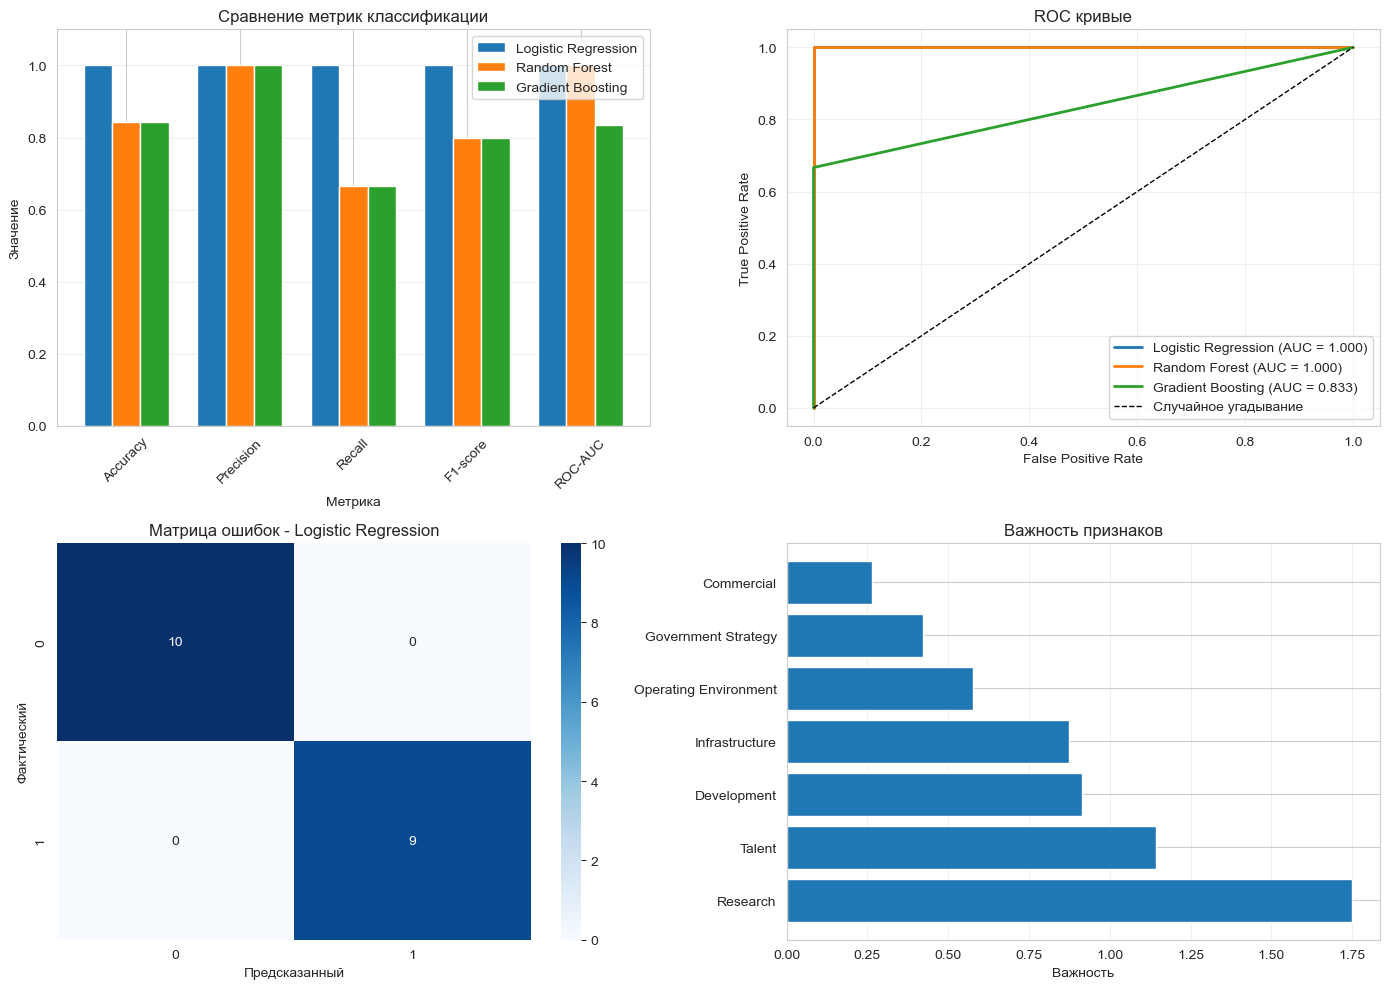

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
metrics_mapping = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'Recall': 'recall',
    'F1-score': 'f1',
    'ROC-AUC': 'roc_auc'
}

x = np.arange(len(metrics))
width = 0.25

for i, (name, result) in enumerate(results.items()):
    values = [result[metrics_mapping[m]] for m in metrics]
    axes[0, 0].bar(x + i*width, values, width, label=name)

axes[0, 0].set_xlabel('Метрика')
axes[0, 0].set_ylabel('Значение')
axes[0, 0].set_title('Сравнение метрик классификации')
axes[0, 0].set_xticks(x + width)
axes[0, 0].set_xticklabels(metrics, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim(0, 1.1)

for name, result in results.items():
    model = result['model']
    if name == 'Logistic Regression':
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    axes[0, 1].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {result["roc_auc"]:.3f})')

axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайное угадывание')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC кривые')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(alpha=0.3)

if best_model_name == 'Logistic Regression':
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_xlabel('Предсказанный')
axes[1, 0].set_ylabel('Фактический')
axes[1, 0].set_title(f'Матрица ошибок - {best_model_name}')

if best_model_name in ['Random Forest', 'Gradient Boosting']:
    importances = best_model.feature_importances_
else:
    importances = np.abs(results['Logistic Regression']['model'].coef_[0])

indices = np.argsort(importances)[::-1]
axes[1, 1].barh(range(len(features_class)), importances[indices])
axes[1, 1].set_yticks(range(len(features_class)))
axes[1, 1].set_yticklabels([features_class[i] for i in indices])
axes[1, 1].set_xlabel('Важность')
axes[1, 1].set_title('Важность признаков')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [94]:
print("ОТЧЕТ ПО КЛАССИФИКАЦИИ")
print()

if best_model_name == 'Logistic Regression':
    print(classification_report(y_test, best_model.predict(X_test_scaled),
                                target_names=['Low AI', 'High AI']))
else:
    print(classification_report(y_test, best_model.predict(X_test),
                                target_names=['Low AI', 'High AI']))

print()
print("ИТОГОВЫЙ ВЫВОД")
print()
print(f"Лучшая модель: {best_model_name}")
print(f"Точность (Accuracy): {results[best_model_name]['accuracy']:.4f}")
print(f"ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print()
print(f"Модель правильно классифицирует {results[best_model_name]['accuracy']*100:.1f}% стран")
print(f"Способность различать классы (ROC-AUC): {results[best_model_name]['roc_auc']*100:.1f}%")

ОТЧЕТ ПО КЛАССИФИКАЦИИ

              precision    recall  f1-score   support

      Low AI       1.00      1.00      1.00        10
     High AI       1.00      1.00      1.00         9

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19


ИТОГОВЫЙ ВЫВОД

Лучшая модель: Logistic Regression
Точность (Accuracy): 1.0000
ROC-AUC: 1.0000

Модель правильно классифицирует 100.0% стран
Способность различать классы (ROC-AUC): 100.0%


# Интерактивный дашборд

https://datalens.ru/1532wzgg12pok-analiz-indeksa-iskusstvennogo-intellekta?_share_link=org

# Приложение для анализа данных AI Index с использованием Streamlit и FastAPI.

Смотрите файл Ai_Index_App.zip